# Note, DDF schedule subject to change depending on weather and updates to survey strategy

In [2]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
#from grab_ddf_sched import grab_ddf_sched
import pandas as pd

In [6]:
# Check the telescope config, download the save file 
# that has planned DDF observations, return array.
# Will skip download if file already exists
#ddf_array = grab_ddf_sched()
ddf_load = np.load("/Users/yoachim/rubin_sim_data/scheduler/ts_ddf_array_3d1ec01.npz")
ddf_array = ddf_load["obs_array"]
ddf_load.close()



In [7]:
# ddf_array is a ScheduledObservationArray object--defined here:
# https://github.com/lsst/rubin_scheduler/blob/main/rubin_scheduler/scheduler/utils/observation_array.py
ddf_array.dtype.names

('ID',
 'RA',
 'dec',
 'mjd',
 'flush_by_mjd',
 'exptime',
 'band',
 'filter',
 'rotSkyPos',
 'rotTelPos',
 'rotTelPos_backup',
 'rotSkyPos_desired',
 'nexp',
 'scheduler_note',
 'target_name',
 'science_program',
 'observation_reason',
 'extinction_limit',
 'mjd_tol',
 'dist_tol',
 'alt_min',
 'alt_max',
 'HA_max',
 'HA_min',
 'sun_alt_max',
 'moon_min_distance',
 'observed')

In [8]:
# Pretty pandas formatting.

# Note all angles (RA, dec, etc) are in radians.
# Hour Angle limits (HA_max, and HA_min) are in hours.

# Some values can be filled or altered at observations time. E.g., 
# the telescope rotation is typically set, and the RA and dec are shifted
# to a dithered position. The filter column will be filled with the 
# filter name used at the summit using the value in "band". 

# This array has all of the "observed" field set to False because
# we have not checked completed observations to see whish should
# be set to True. 
pd.DataFrame(ddf_array)

,ID,RA,dec,mjd,flush_by_mjd,exptime,band,filter,rotSkyPos,rotTelPos,...,extinction_limit,mjd_tol,dist_tol,alt_min,alt_max,HA_max,HA_min,sun_alt_max,moon_min_distance,observed
0,0,0.620901,-0.084067,61347.270833,61349.270833,38.0,u,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
1,0,0.620901,-0.084067,61347.270833,61349.270833,38.0,u,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
2,0,0.620901,-0.084067,61347.270833,61349.270833,38.0,u,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
3,0,0.620901,-0.084067,61348.173610,61350.173610,38.0,u,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
4,0,0.620901,-0.084067,61348.173610,61350.173610,38.0,u,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182770,0,1.110029,-0.830777,62160.055554,62162.055554,30.0,z,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
182771,0,1.110029,-0.830777,62160.055554,62162.055554,30.0,z,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
182772,0,1.110029,-0.830777,62160.055554,62162.055554,30.0,z,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False
182773,0,1.110029,-0.830777,62160.055554,62162.055554,30.0,z,,0.0,0.0,...,100.0,0.010417,0.05236,0.436332,1.48353,3.0,21.0,-0.314159,0.436332,False


In [9]:
u_targets = np.unique(ddf_array["target_name"])

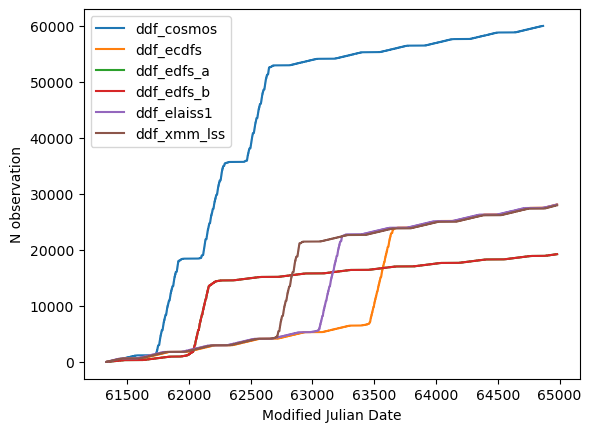

In [10]:
fig, ax = plt.subplots()
for target in u_targets:
    good = np.where(ddf_array["target_name"] == target)[0]
    num = np.arange(good.size)
    mjd = ddf_array["mjd"][good]
    ax.plot(np.sort(mjd), num, label=target)
ax.legend()
#plt.ylim([10,1e5])
ax.set_xlabel("Modified Julian Date")
ax.set_ylabel("N observation")

fig.savefig("ddf_schedule.png")